<a href="https://colab.research.google.com/github/krishshah8000/Deep-learning/blob/main/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

# Display the description of the dataset
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

boston_df = pd.DataFrame(data)
boston_df['target'] = target

display(boston_df)

,0,1,2,3,4,5,6,7,8,9,10,11,12,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [ ]:
print("Null values per column:\n", boston_df.isnull().sum())
print("\nNumber of duplicate rows:", boston_df.duplicated().sum())

Null values per column:
 0         0
1         0
2         0
3         0
4         0
5         0
6         0
7         0
8         0
9         0
10        0
11        0
12        0
target    0
dtype: int64

Number of duplicate rows: 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = boston_df.drop('target', axis=1)
y = boston_df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalized and data split successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features normalized and data split successfully.
X_train_scaled shape: (404, 13)
X_test_scaled shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

def build_and_train_model(learning_rate, X_train_scaled, y_train, X_test_scaled, y_test, epochs=100):
    # Build the Keras sequential model
    model = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1) # Output layer for regression
    ])

    # Compile the model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    print(f"\nTraining model with learning rate: {learning_rate}")
    # Train the model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        validation_split=0.2, # Use 20% of training data for validation
        verbose=0 # Suppress verbose output during training
    )

    # Evaluate the model
    loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss:.4f}, Test MAE: {mae:.4f} for LR {learning_rate}")

    return history, model

learning_rates = [0.1, 0.01, 0.001]
histories = {}
models = {}

for lr in learning_rates:
    history, model = build_and_train_model(lr, X_train_scaled, y_train, X_test_scaled, y_test)
    histories[lr] = history
    models[lr] = model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training model with learning rate: 0.1
Test Loss (MSE): 11.3678, Test MAE: 2.3935 for LR 0.1

Training model with learning rate: 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 12.6170, Test MAE: 2.3144 for LR 0.01

Training model with learning rate: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 13.4465, Test MAE: 2.4958 for LR 0.001


Now, let's plot the training and validation loss for each learning rate to observe their impact on model performance.

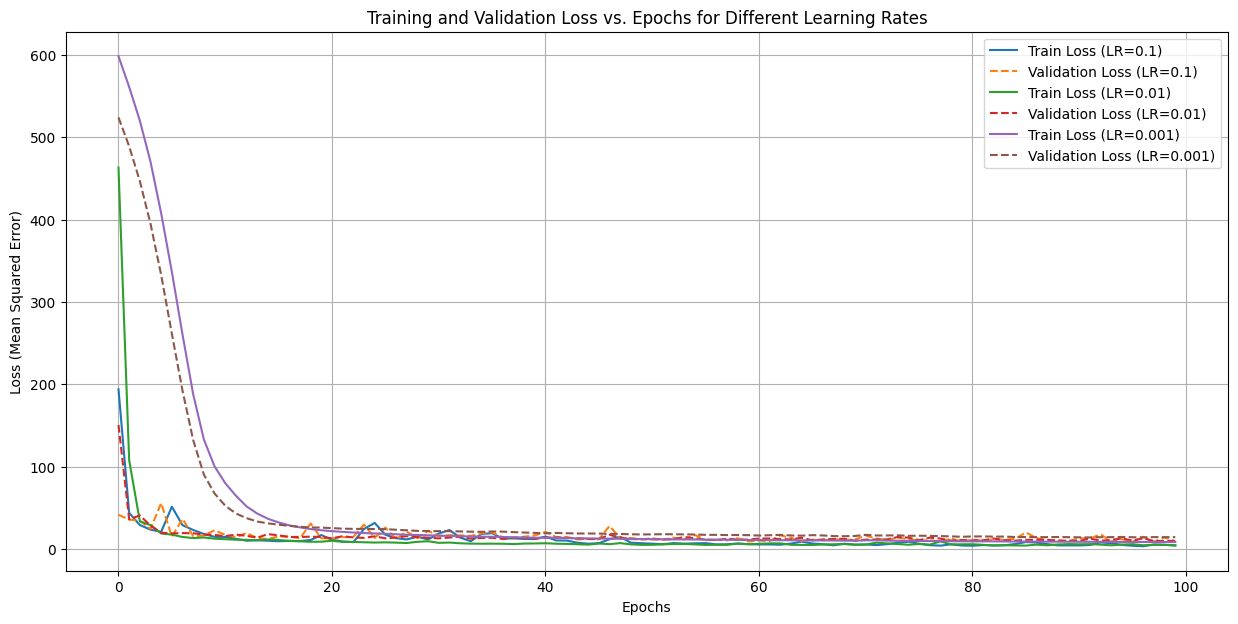

In [ ]:
plt.figure(figsize=(15, 7))

for lr, history in histories.items():
    plt.plot(history.history['loss'], label=f'Train Loss (LR={lr})')
    plt.plot(history.history['val_loss'], label=f'Validation Loss (LR={lr})', linestyle='--')

plt.title('Training and Validation Loss vs. Epochs for Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_lr = None
min_val_mae = float('inf')

print("Validation MAE for each learning rate:")
for lr, history in histories.items():
    final_val_mae = history.history['val_mae'][-1]
    print(f"  LR {lr}: {final_val_mae:.4f}")
    if final_val_mae < min_val_mae:
        min_val_mae = final_val_mae
        best_lr = lr

print(f"\nThe best learning rate based on validation MAE is: {best_lr}")


Validation MAE for each learning rate:
  LR 0.1: 2.3053
  LR 0.01: 2.2408
  LR 0.001: 2.6831

The best learning rate based on validation MAE is: 0.01


In [ ]:
print("Validation MSE for each learning rate:")
for lr, history in histories.items():
    final_val_mse = history.history['val_loss'][-1] # 'loss' typically refers to MSE
    print(f"  LR {lr}: {final_val_mse:.4f}")


Validation MSE for each learning rate:
  LR 0.1: 9.3953
  LR 0.01: 9.8120
  LR 0.001: 14.4585


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Predictions using the model with best learning rate (0.01):
Actual: 23.60, Predicted: 27.63
Actual: 32.40, Predicted: 37.36
Actual: 13.60, Predicted: 17.30
Actual: 22.80, Predicted: 24.25
Actual: 16.10, Predicted: 16.63
Actual: 20.00, Predicted: 20.12
Actual: 17.80, Predicted: 17.84
Actual: 14.00, Predicted: 15.56
Actual: 19.60, Predicted: 23.44
Actual: 16.80, Predicted: 19.05


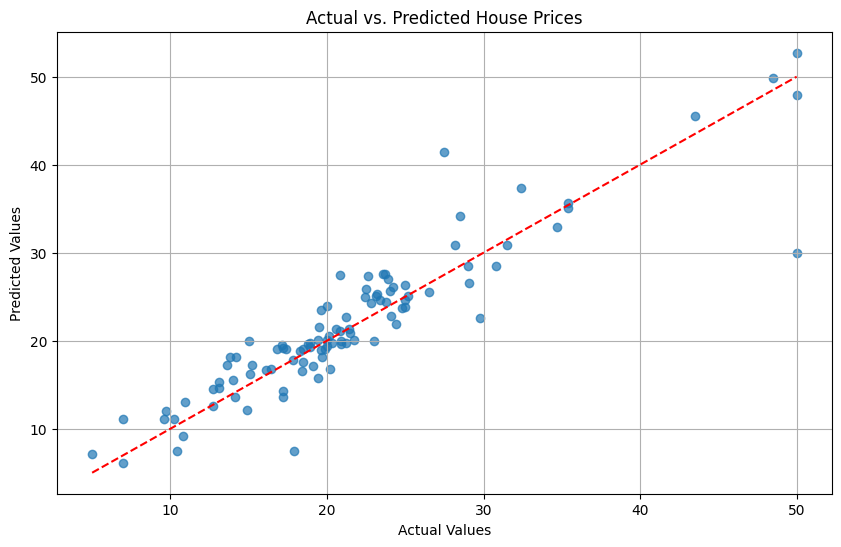

In [ ]:
best_model = models[best_lr]
predictions = best_model.predict(X_test_scaled).flatten()

print(f"\nPredictions using the model with best learning rate ({best_lr}):")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {predictions[i]:.2f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted House Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Continuing training with Leaky ReLU and ELU activation functions...

Training model with learning rate: 0.01, Activation: <LeakyReLU name=leaky_re_lu, built=True>
Test Loss (MSE): 12.4675, Test MAE: 2.2729 for LR 0.01, Activation: <LeakyReLU name=leaky_re_lu, built=True>

Training model with learning rate: 0.001, Activation: <LeakyReLU name=leaky_re_lu, built=True>


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 13.4026, Test MAE: 2.4627 for LR 0.001, Activation: <LeakyReLU name=leaky_re_lu, built=True>

Training model with learning rate: 0.01, Activation: elu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 12.5238, Test MAE: 2.5787 for LR 0.01, Activation: elu

Training model with learning rate: 0.001, Activation: elu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Loss (MSE): 13.0221, Test MAE: 2.2261 for LR 0.001, Activation: elu

Training with new activation functions complete.


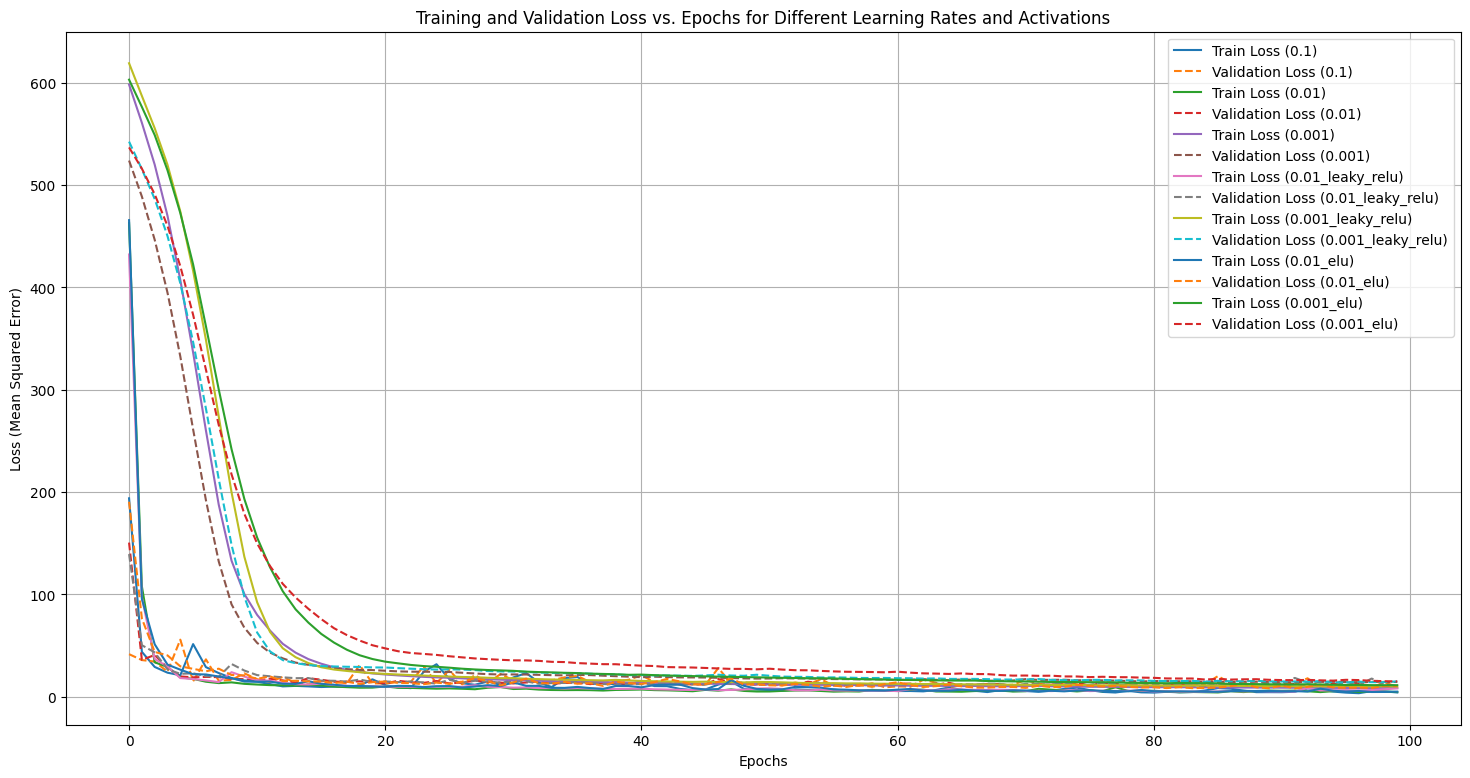


Validation MAE for all models:
  0.1: 2.3053
  0.01: 2.2408
  0.001: 2.6831
  0.01_leaky_relu: 2.2652
  0.001_leaky_relu: 2.6315
  0.01_elu: 2.4893
  0.001_elu: 2.5738

Overall best model based on validation MAE: 0.01 with MAE: 2.2408
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Predictions using the overall best model (0.01):
Actual: 23.60, Predicted: 27.63
Actual: 32.40, Predicted: 37.36
Actual: 13.60, Predicted: 17.30
Actual: 22.80, Predicted: 24.25
Actual: 16.10, Predicted: 16.63
Actual: 20.00, Predicted: 20.12
Actual: 17.80, Predicted: 17.84
Actual: 14.00, Predicted: 15.56
Actual: 19.60, Predicted: 23.44
Actual: 16.80, Predicted: 19.05


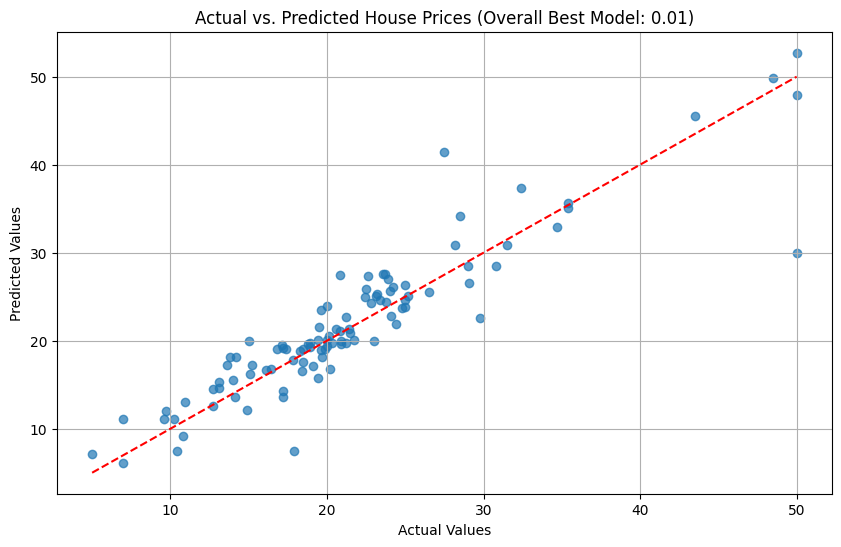

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LeakyReLU, ELU # Import new activation functions
import matplotlib.pyplot as plt

# Redefine the build_and_train_model function to accept an activation function
def build_and_train_model(learning_rate, X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, activation_fn='relu'):
    # Build the Keras sequential model
    # Use the passed activation_fn for the hidden layers
    model = keras.Sequential([
        layers.Dense(64, activation=activation_fn, input_shape=(X_train_scaled.shape[1],)),
        layers.Dense(32, activation=activation_fn),
        layers.Dense(1) # Output layer for regression
    ])

    # Compile the model
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    print(f"\nTraining model with learning rate: {learning_rate}, Activation: {activation_fn}")
    # Train the model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        validation_split=0.2, # Use 20% of training data for validation
        verbose=0 # Suppress verbose output during training
    )

    # Evaluate the model
    loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"Test Loss (MSE): {loss:.4f}, Test MAE: {mae:.4f} for LR {learning_rate}, Activation: {activation_fn}")

    return history, model

# Re-use the best learning rate identified previously (0.01) and also try 0.001
learning_rates_for_new_activations = [0.01, 0.001]
activation_functions = {'leaky_relu': LeakyReLU(alpha=0.2), 'elu': 'elu'}

# Assuming 'histories' and 'models' from previous cell are still in scope.
# These dictionaries already contain the 'relu' results. Let's extend them.

print("Continuing training with Leaky ReLU and ELU activation functions...")

for activation_name, activation_fn in activation_functions.items():
    for lr in learning_rates_for_new_activations:
        history, model = build_and_train_model(
            lr, X_train_scaled, y_train, X_test_scaled, y_test,
            activation_fn=activation_fn
        )
        # Store results with a unique key combining LR and activation name
        histories[f'{lr}_{activation_name}'] = history
        models[f'{lr}_{activation_name}'] = model

print("\nTraining with new activation functions complete.")

# Now, plot the training and validation loss for all histories (including previous 'relu' and new activations)
plt.figure(figsize=(18, 9))

for key, history in histories.items():
    plt.plot(history.history['loss'], label=f'Train Loss ({key})')
    plt.plot(history.history['val_loss'], label=f'Validation Loss ({key})', linestyle='--')

plt.title('Training and Validation Loss vs. Epochs for Different Learning Rates and Activations')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

# Print validation MAE for all models for comparison
print("\nValidation MAE for all models:")
overall_best_key = None
overall_min_val_mae = float('inf')

for key, history in histories.items():
    final_val_mae = history.history['val_mae'][-1]
    print(f"  {key}: {final_val_mae:.4f}")
    if final_val_mae < overall_min_val_mae:
        overall_min_val_mae = final_val_mae
        overall_best_key = key

print(f"\nOverall best model based on validation MAE: {overall_best_key} with MAE: {overall_min_val_mae:.4f}")

# Get the overall best model and make predictions
best_model_overall = models[overall_best_key]
predictions_overall = best_model_overall.predict(X_test_scaled).flatten()

print(f"\nPredictions using the overall best model ({overall_best_key}):")
for i in range(10):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {predictions_overall[i]:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions_overall, alpha=0.7)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs. Predicted House Prices (Overall Best Model: {overall_best_key})")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.grid(True)
plt.show()